# Overfishing of the Blue Whiting
#### In this notebook you'll find statistic analysis and visualisations for the project

In [1]:
import sys
print(sys.executable)

/Users/llabarga/myenv/bin/python


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

#### We start by importing and cleaning data

In [4]:
datos = pd.read_csv('bluewhiting_data.csv')
datos

,Zone,TL,Weight,Sex,Maturity,Age
0,Atlàntic,24.0,83.33,F,M,1.5
1,Atlàntic,24.1,84.54,F,M,3.0
2,Atlàntic,25.0,92.06,F,M,1.5
3,Atlàntic,23.1,82.66,M,M,2.5
4,Atlàntic,26.6,103.07,F,M,5.0
...,...,...,...,...,...,...
147,Mediterrani,25.0,106.39,I,I,2.5
148,Mediterrani,20.0,49.08,I,I,1.0
149,Mediterrani,21.1,57.93,I,I,3.0
150,Mediterrani,20.1,53.05,I,I,3.5


In [5]:
datos["Zone"] = datos["Zone"].replace({
    "Mediterrani": "Mediterranean",
    "Atlàntic": "Atlantic"
})
datos   
# This changes categories from Catalan to English

,Zone,TL,Weight,Sex,Maturity,Age
0,Atlantic,24.0,83.33,F,M,1.5
1,Atlantic,24.1,84.54,F,M,3.0
2,Atlantic,25.0,92.06,F,M,1.5
3,Atlantic,23.1,82.66,M,M,2.5
4,Atlantic,26.6,103.07,F,M,5.0
...,...,...,...,...,...,...
147,Mediterranean,25.0,106.39,I,I,2.5
148,Mediterranean,20.0,49.08,I,I,1.0
149,Mediterranean,21.1,57.93,I,I,3.0
150,Mediterranean,20.1,53.05,I,I,3.5


In [6]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Zone      152 non-null    str    
 1   TL        152 non-null    float64
 2   Weight    152 non-null    float64
 3   Sex       152 non-null    str    
 4   Maturity  152 non-null    str    
 5   Age       152 non-null    float64
dtypes: float64(3), str(3)
memory usage: 7.3 KB


In [20]:
datos["Age"] = datos["Age"].astype(str)
datos.info()
# Here the category "age" was considered float64 so I changed it to string

<class 'pandas.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Zone      152 non-null    str    
 1   TL        152 non-null    float64
 2   Weight    152 non-null    float64
 3   Sex       152 non-null    str    
 4   Maturity  152 non-null    str    
 5   Age       152 non-null    str    
dtypes: float64(2), str(4)
memory usage: 7.3 KB


#### Results

Total length

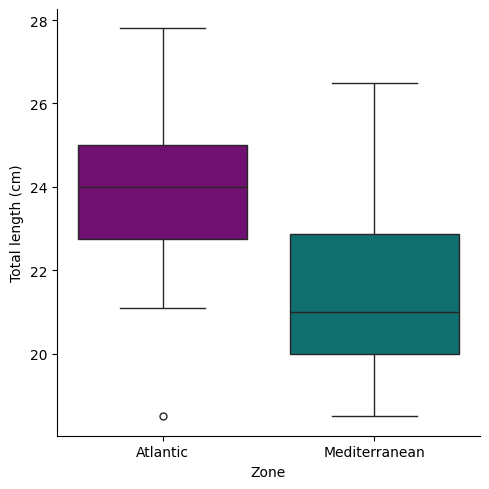

In [21]:
g1= sns.catplot(
    data=datos, 
    x='Zone', 
    y='TL', 
    kind='box',
    hue='Zone',palette={'Atlantic':'purple', 'Mediterranean':'teal'}
)
g1.set_axis_labels("Zone","Total length (cm)")


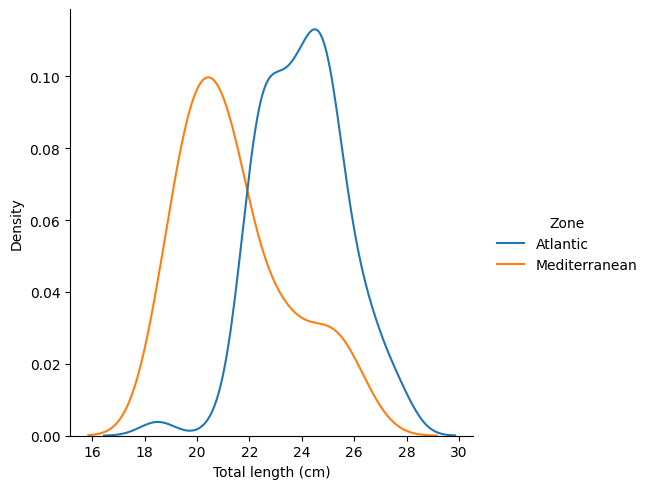

In [22]:
g2 =sns.displot(data=datos, 
            x='TL', 
            kind='kde', 
            hue='Zone')
g2.set_axis_labels("Total length (cm)","Density")

Total length and weight relationship

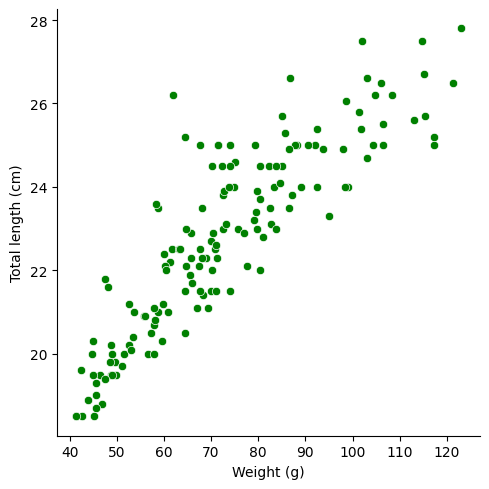

In [10]:
g3= sns.relplot(
    data=datos, 
    x='Weight', 
    y='TL', 
    color='green')
g3.set_axis_labels("Weight (g)","Total length (cm)")

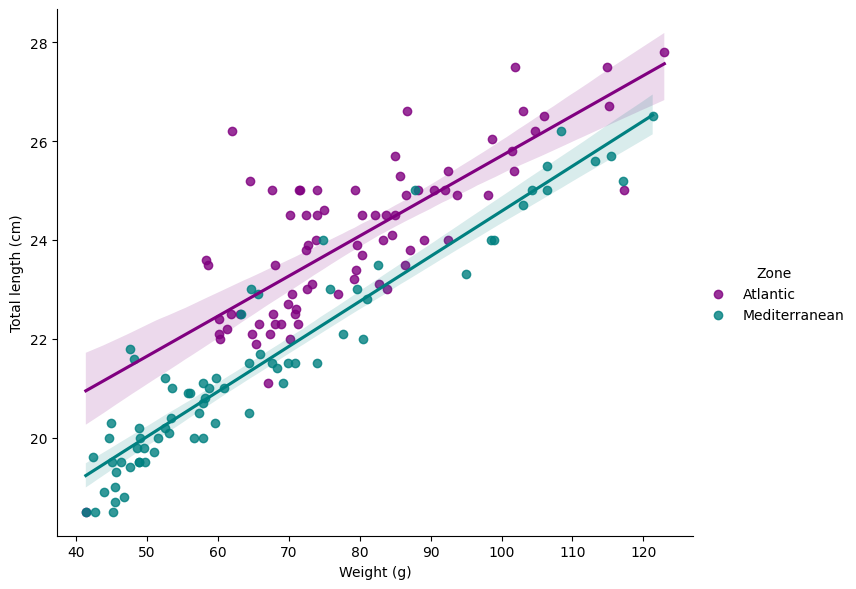

In [11]:
g4= sns.lmplot(
    data=datos, 
    x='Weight', 
    y='TL', 
    hue='Zone', 
    height=6, 
    aspect=1.2, 
    palette={'Atlantic':'purple', 'Mediterranean':'teal'}
)
g4.set_axis_labels("Weight (g)","Total length (cm)")


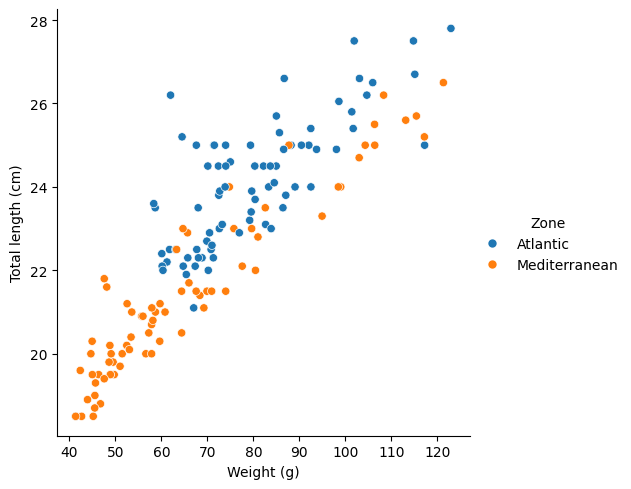

In [12]:
g5= sns.relplot(data=datos, 
            x='Weight', 
            y='TL',
            hue='Zone')
g5.set_axis_labels("Weight (g)","Total length (cm)")

Maturity

In [13]:
datos.Maturity = datos.Maturity.str.strip()
datos

,Zone,TL,Weight,Sex,Maturity,Age
0,Atlantic,24.0,83.33,F,M,1.5
1,Atlantic,24.1,84.54,F,M,3.0
2,Atlantic,25.0,92.06,F,M,1.5
3,Atlantic,23.1,82.66,M,M,2.5
4,Atlantic,26.6,103.07,F,M,5.0
...,...,...,...,...,...,...
147,Mediterranean,25.0,106.39,I,I,2.5
148,Mediterranean,20.0,49.08,I,I,1.0
149,Mediterranean,21.1,57.93,I,I,3.0
150,Mediterranean,20.1,53.05,I,I,3.5


In [14]:
# Separate data in zones
atlantic = datos[datos['Zone'] == 'Atlantic']
mediterranean = datos[datos['Zone'] == 'Mediterranean']

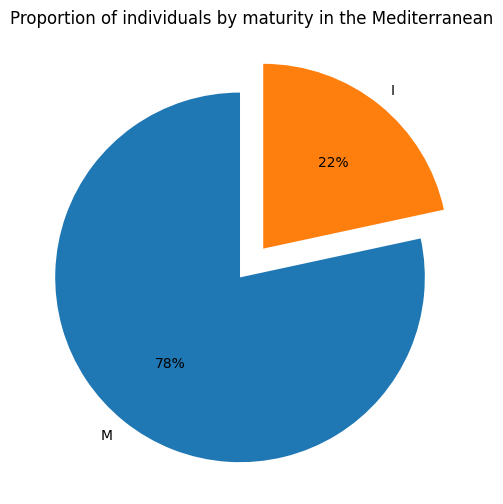

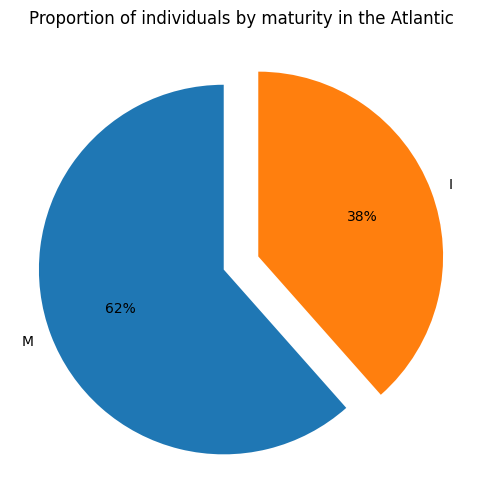

In [15]:
# Count mature and inmature indivuals in Atlantic
counts_atlantic = atlantic['Maturity'].value_counts()
labels_atlantic = counts_atlantic.index.tolist()
sizes_atlantic = counts_atlantic.values.tolist()
explode_atlantic = [0.1] * len(labels_atlantic)

# Count mature and inmature indivuals in Mediterranean
counts_mediterranean = mediterranean['Maturity'].value_counts()
labels_mediterranean = counts_mediterranean.index.tolist()
sizes_mediterranean = counts_mediterranean.values.tolist()
explode_mediterranean = [0.1] * len(labels_mediterranean)

#Create piecharts
plt.figure(figsize=(6,6))
plt.pie(sizes_mediterranean, labels=labels_mediterranean, autopct='%.0f%%', explode=explode_mediterranean, startangle=90)
plt.title('Proportion of individuals by maturity in the Mediterranean')
plt.show()

plt.figure(figsize=(6,6))
plt.pie(sizes_atlantic, labels=labels_atlantic, autopct='%.0f%%', explode=explode_atlantic, startangle=90)
plt.title('Proportion of individuals by maturity in the Atlantic')
plt.show()

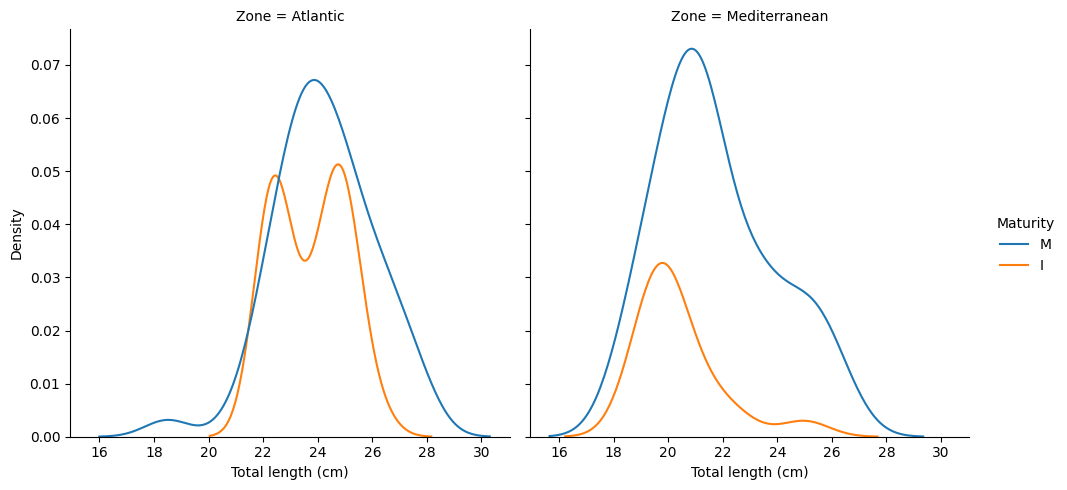

In [16]:
g6= sns.displot(data=datos, 
            x='TL', 
            kind='kde', 
            hue='Maturity',
            col='Zone')
g6.set_axis_labels("Total length (cm)","Density")

Text(0.5, 1.0, 'Mediterranean')

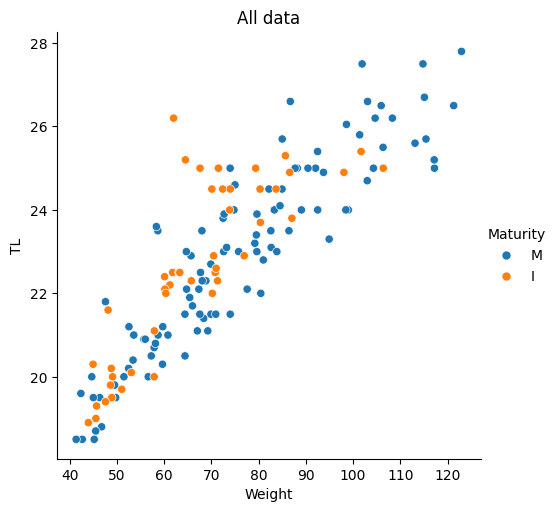

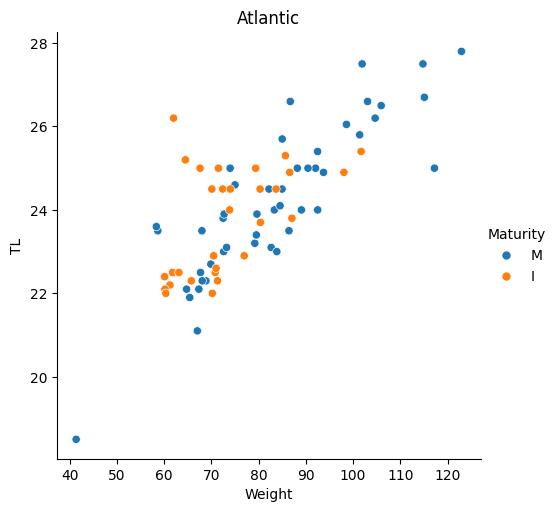

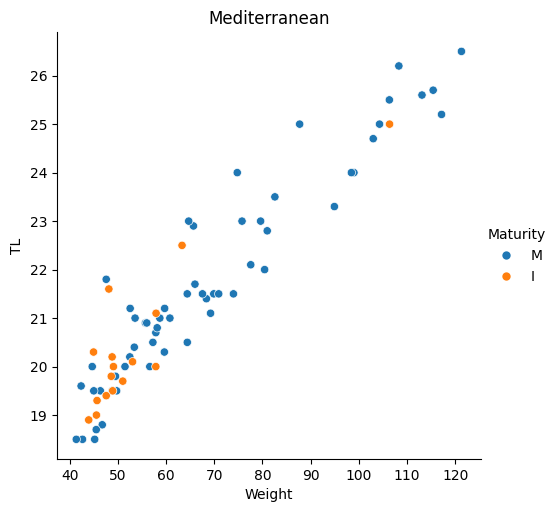

In [17]:
sns.relplot(data=datos, x='Weight', y='TL', hue='Maturity')
plt.title("All data")
sns.relplot(data=atlantic, x='Weight', y='TL', hue='Maturity')
plt.title("Atlantic")
sns.relplot(data=mediterranean, x='Weight', y='TL', hue='Maturity', )
plt.title("Mediterranean")

Age and maturity

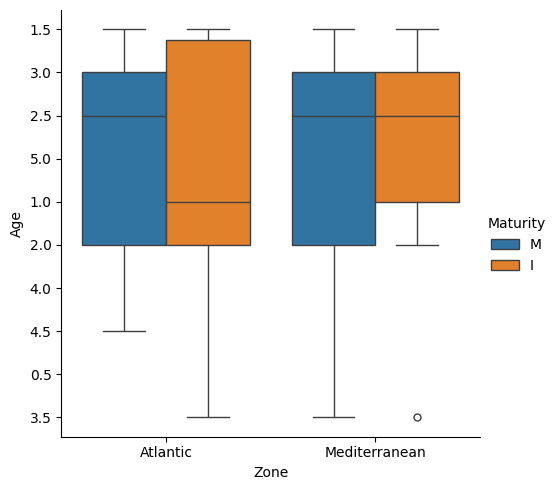

In [18]:
sns.catplot(data=datos, x='Zone', y='Age', hue='Maturity', kind='box')

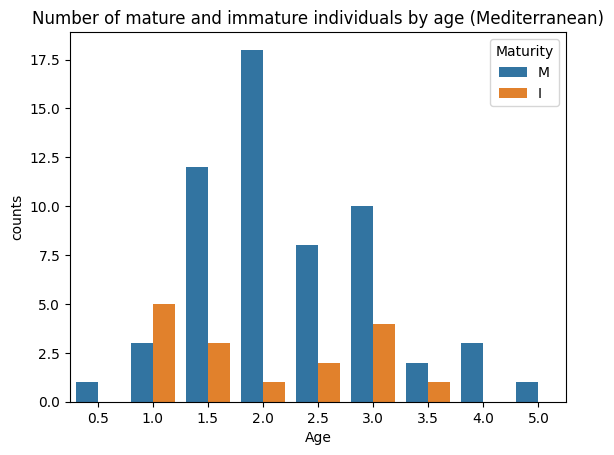

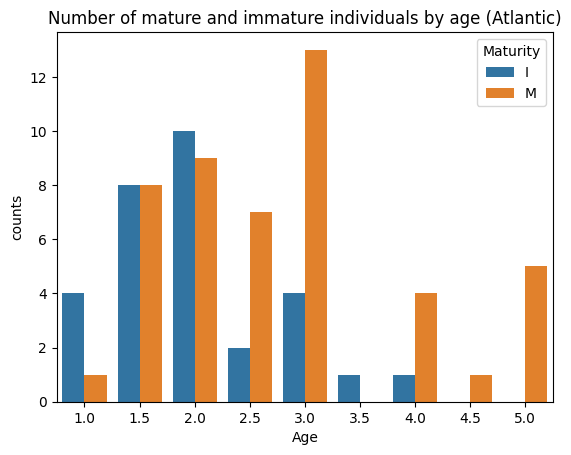

In [19]:
# Group by age and maturity and count individuals
conteosM = mediterranean.groupby(['Age', 'Maturity']).size().reset_index(name='counts')
conteosA = atlantic.groupby(['Age', 'Maturity']).size().reset_index(name='counts')
# Create barplot
sns.barplot(data=conteosM, x='Age', y='counts', hue='Maturity')
plt.title('Number of mature and immature individuals by age (Mediterranean)')
plt.show()

sns.barplot(data=conteosA, x='Age', y='counts', hue='Maturity')
plt.title('Number of mature and immature individuals by age (Atlantic)')
plt.show()

